In [138]:
# ============================================================
# RNN / GRU inverse model for SCR pre-exponential factors
# First trial: 1000 datasets = 800 train + 100 val + 100 test
# ============================================================

import os
from pathlib import Path
import numpy as np
import scipy.io as sio
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

## Load data

In [139]:
outputs_train = np.load("../Data/outputs_train.npy").astype(np.float32)
outputs_val   = np.load("../Data/outputs_val.npy").astype(np.float32)
outputs_test  = np.load("../Data/outputs_test.npy").astype(np.float32)

As_train = np.load("../Data/ks_train.npy").astype(np.float64)
As_val   = np.load("../Data/ks_val.npy").astype(np.float64)
As_test  = np.load("../Data/ks_test.npy").astype(np.float64)

print("outputs_train:", outputs_train.shape)
print("outputs_val:  ", outputs_val.shape)
print("outputs_test: ", outputs_test.shape)

print("As_train:", As_train.shape)
print("As_val:  ", As_val.shape)
print("As_test: ", As_test.shape)

print("Total datasets:", len(As_train) + len(As_val) + len(As_test))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device =", device)

outputs_train: (800, 11993)
outputs_val:   (100, 11993)
outputs_test:  (100, 11993)
As_train: (800, 6)
As_val:   (100, 6)
As_test:  (100, 6)
Total datasets: 1000
device = cpu


## Load operating-condition signals from NEDC_lite.mat

In [140]:
mat_path = "../Data/NEDC_lite.mat"

mat = sio.loadmat(mat_path, squeeze_me=True, struct_as_record=False)

def get_signal(name):
    return np.asarray(mat[name].signals.values, dtype=np.float32).reshape(-1)

F_NOx = get_signal("F_NOx_sensor")    # upstream NOx
Temp = get_signal("Temp")             # exhaust temp
O2 = get_signal("O2")                 # O2
ExhaustFlow = get_signal("ExhaustFlow")
Adblue = get_signal("adblue_mg")      # Adblue signal

# Common signals for all simulations
# Shape: [time, 5]
base_signals = np.stack(
    [F_NOx, Temp, O2, ExhaustFlow, Adblue],
    axis=1
)

print("base_signals:", base_signals.shape)

base_signals: (11993, 5)


## Downsample for first trial

In [141]:
# Full length is 11993, which can be slow for RNN.
# DOWNSAMPLE = 10 gives around 1200 time steps.
# Later, try DOWNSAMPLE = 5 or 1.
DOWNSAMPLE = 1

base_signals = base_signals[::DOWNSAMPLE]
outputs_train = outputs_train[:, ::DOWNSAMPLE]
outputs_val   = outputs_val[:, ::DOWNSAMPLE]
outputs_test  = outputs_test[:, ::DOWNSAMPLE]

print("After downsampling:")
print("base_signals:", base_signals.shape)
print("outputs_train:", outputs_train.shape)


After downsampling:
base_signals: (11993, 5)
outputs_train: (800, 11993)


## Input scaling

In [142]:
# Per-channel min-max scaling for common operating signals
base_min = base_signals.min(axis=0, keepdims=True)
base_max = base_signals.max(axis=0, keepdims=True)

base_scaled = (base_signals - base_min) / (base_max - base_min + 1e-8)

# Downstream NOx scaling using train set only
dno_min = outputs_train.min()
dno_max = outputs_train.max()

def scale_dno(x):
    return (x - dno_min) / (dno_max - dno_min + 1e-8)

outputs_train_scaled = scale_dno(outputs_train)
outputs_val_scaled   = scale_dno(outputs_val)
outputs_test_scaled  = scale_dno(outputs_test)


## Label scaling: log10(k), then z-normalization

In [143]:
param_names = [
    "A_ads",
    "A_des",
    "A_std",
    "A_fst",
    "A_slw",
    "A_nh3ox",
]

logA_train = np.log10(As_train)
logA_val   = np.log10(As_val)
logA_test  = np.log10(As_test)

A_mean = logA_train.mean(axis=0, keepdims=True)
A_std = logA_train.std(axis=0, keepdims=True) + 1e-8

y_train = ((logA_train - A_mean) / A_std).astype(np.float32)
y_val   = ((logA_val   - A_mean) / A_std).astype(np.float32)
y_test  = ((logA_test  - A_mean) / A_std).astype(np.float32)

print("y_train:", y_train.shape)
print("y_val:  ", y_val.shape)
print("y_test: ", y_test.shape)

def inverse_transform_A(y_scaled):
    """
    Convert normalized network output back to physical A values.
    """
    y_scaled = np.asarray(y_scaled)
    logA = y_scaled * A_std + A_mean
    return 10 ** logA


y_train: (800, 6)
y_val:   (100, 6)
y_test:  (100, 6)


## Dataset

In [144]:
class SCRSequenceDataset(Dataset):
    def __init__(self, outputs_scaled, labels_scaled, base_scaled):
        self.outputs_scaled = outputs_scaled.astype(np.float32)
        self.labels_scaled = labels_scaled.astype(np.float32)
        self.base_scaled = base_scaled.astype(np.float32)

    def __len__(self):
        return self.outputs_scaled.shape[0]

    def __getitem__(self, idx):
        # downstream NOx for this simulation
        dno = self.outputs_scaled[idx][:, None]   # [time, 1]

        # input sequence:
        # [F_NOx, Temp, O2, ExhaustFlow, Adblue, downstream_NOx]
        x = np.concatenate([self.base_scaled, dno], axis=1)  # [time, 6]

        y = self.labels_scaled[idx]  # [6]

        return torch.from_numpy(x), torch.from_numpy(y)


train_ds = SCRSequenceDataset(outputs_train_scaled, y_train, base_scaled)
val_ds   = SCRSequenceDataset(outputs_val_scaled,   y_val,   base_scaled)
test_ds  = SCRSequenceDataset(outputs_test_scaled,  y_test,  base_scaled)

BATCH_SIZE = 16

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

x0, y0 = train_ds[0]
print("One input sequence shape:", x0.shape)
print("One label shape:", y0.shape)


One input sequence shape: torch.Size([11993, 6])
One label shape: torch.Size([6])


## RNN model

In [145]:
class SCR_GRU(nn.Module):
    def __init__(
        self,
        input_size=6,
        hidden_size=64,
        num_layers=2,
        output_size=6,
        dropout=0.10,
        bidirectional=True,
    ):
        super().__init__()

        self.bidirectional = bidirectional

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=bidirectional,
        )

        head_input_size = hidden_size * (2 if bidirectional else 1)

        self.head = nn.Sequential(
            nn.Linear(head_input_size, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, output_size),
        )

    def forward(self, x):
        # x shape: [batch, time, features]
        _, h = self.gru(x)

        if self.bidirectional:
            # last layer forward and backward hidden states
            z = torch.cat([h[-2], h[-1]], dim=1)
        else:
            z = h[-1]

        return self.head(z)


model = SCR_GRU(
    input_size=6,
    hidden_size=64,
    num_layers=2,
    output_size=6,
    dropout=0.10,
    bidirectional=True,
).to(device)

print(model)



SCR_GRU(
  (gru): GRU(6, 64, num_layers=2, batch_first=True, dropout=0.1, bidirectional=True)
  (head): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=64, out_features=6, bias=True)
  )
)


## Training setup

In [146]:
criterion = nn.MSELoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-5,
)

EPOCHS = 200
PATIENCE = 25
GRAD_CLIP = 1.0


def run_one_epoch(model, loader, train=True):
    if train:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    total_count = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        if train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(train):
            pred = model(x)
            loss = criterion(pred, y)

            if train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                optimizer.step()

        batch_size = x.shape[0]
        total_loss += loss.item() * batch_size
        total_count += batch_size

    return total_loss / total_count

## Train with early stopping

In [147]:
history = {
    "train_loss": [],
    "val_loss": [],
}

best_val_loss = np.inf
best_state = None
bad_epochs = 0

for epoch in range(1, EPOCHS + 1):
    train_loss = run_one_epoch(model, train_loader, train=True)
    val_loss = run_one_epoch(model, val_loader, train=False)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        bad_epochs = 0
    else:
        bad_epochs += 1

    if epoch == 1 or epoch % 10 == 0:
        print(
            f"Epoch {epoch:4d} | "
            f"train_loss = {train_loss:.6e} | "
            f"val_loss = {val_loss:.6e}"
        )

    if bad_epochs >= PATIENCE:
        print(f"Early stopping at epoch {epoch}")
        break

model.load_state_dict(best_state)
print("Best val loss:", best_val_loss)

Epoch    1 | train_loss = 1.004118e+00 | val_loss = 8.888913e-01
Epoch   10 | train_loss = 1.001864e+00 | val_loss = 8.914971e-01
Epoch   20 | train_loss = 1.000686e+00 | val_loss = 8.885515e-01
Early stopping at epoch 29
Best val loss: 0.8853111386299133


## Plot training history

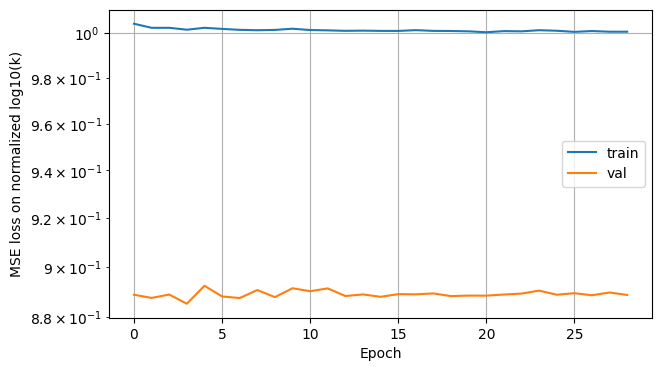

In [148]:
plt.figure(figsize=(7, 4))
plt.plot(history["train_loss"], label="train")
plt.plot(history["val_loss"], label="val")
plt.xlabel("Epoch")
plt.ylabel("MSE loss on normalized log10(k)")
plt.yscale("log")
plt.grid(True)
plt.legend()
plt.show()

## Evaluation helper

In [149]:
def predict_loader(model, loader):
    model.eval()

    preds = []
    trues = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            pred = model(x).cpu().numpy()

            preds.append(pred)
            trues.append(y.numpy())

    preds = np.vstack(preds)
    trues = np.vstack(trues)

    pred_k = inverse_transform_A(preds)
    true_k = inverse_transform_A(trues)

    return pred_k, true_k, preds, trues


pred_A_test, true_A_test, pred_scaled_test, true_scaled_test = predict_loader(model, test_loader)

test_mse_scaled = np.mean((pred_scaled_test - true_scaled_test) ** 2)
test_mse_log10 = np.mean((np.log10(pred_A_test) - np.log10(true_A_test)) ** 2)

print("Test MSE, normalized log10(A):", test_mse_scaled)
print("Test MSE, physical log10(A):  ", test_mse_log10)

Test MSE, normalized log10(A): 0.9632255
Test MSE, physical log10(A):   0.0834584917249829


## Relative error by parameter

In [150]:
rel_err = np.abs(pred_A_test - true_A_test) / (np.abs(true_A_test) + 1e-12)

summary = pd.DataFrame({
    "parameter": param_names,
    "mean_relative_error_%": rel_err.mean(axis=0) * 100,
    "median_relative_error_%": np.median(rel_err, axis=0) * 100,
})

print(summary)

  parameter  mean_relative_error_%  median_relative_error_%
0     A_ads              29.557521                25.387092
1     A_des              17.971769                16.625663
2     A_std              88.039937                49.524182
3     A_fst             142.413016                51.433594
4     A_slw             139.609630                50.986273
5   A_nh3ox              41.963089                30.415241


## Show several predictions

In [151]:
num_show = 5

for i in range(num_show):
    df = pd.DataFrame({
        "parameter": param_names,
        "true_k": true_A_test[i],
        "pred_k": pred_A_test[i],
        "relative_error_%": rel_err[i] * 100,
    })

    print(f"\nTest sample {i}")
    print(df)


Test sample 0
  parameter        true_k        pred_k  relative_error_%
0     A_ads  4.126937e+00  4.055838e+00          1.722800
1     A_des  5.207686e+04  4.756609e+04          8.661761
2     A_std  5.150959e+09  2.726092e+09         47.076032
3     A_fst  1.063610e+10  6.639372e+09         37.577013
4     A_slw  4.462940e+11  2.741322e+11         38.575880
5   A_nh3ox  2.919157e+05  6.453875e+05        121.086934

Test sample 1
  parameter        true_k        pred_k  relative_error_%
0     A_ads  2.925393e+00  4.055833e+00         38.642311
1     A_des  3.967921e+04  4.756608e+04         19.876574
2     A_std  4.139715e+09  2.726095e+09         34.147758
3     A_fst  1.673224e+10  6.639401e+09         60.319712
4     A_slw  3.008185e+11  2.741297e+11          8.872044
5   A_nh3ox  2.683122e+05  6.453884e+05        140.536381

Test sample 2
  parameter        true_k        pred_k  relative_error_%
0     A_ads  4.011236e+00  4.055834e+00          1.111828
1     A_des  6.068677e+04  

## Scatter plot: true vs predicted log10(k)

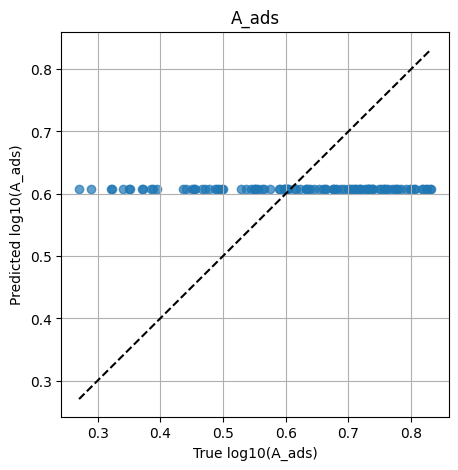

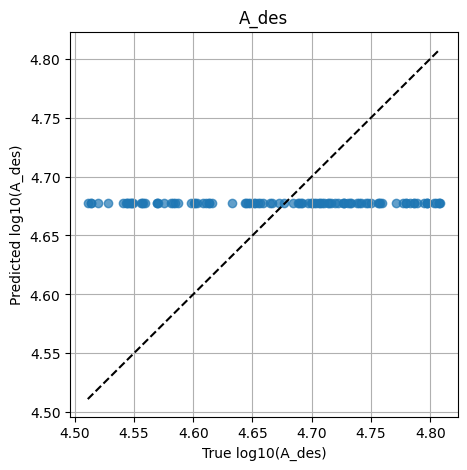

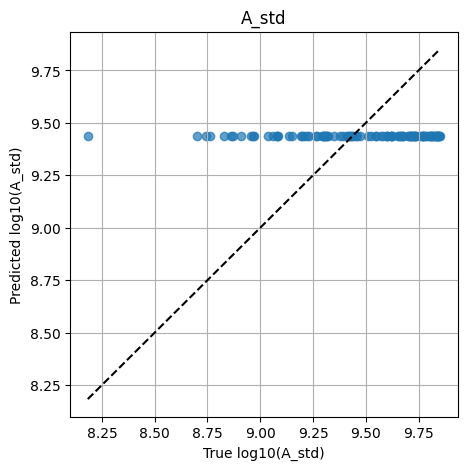

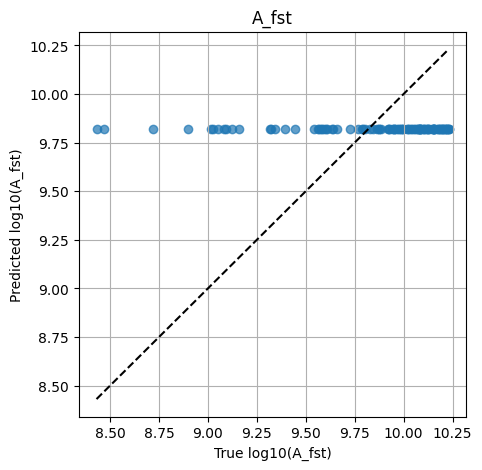

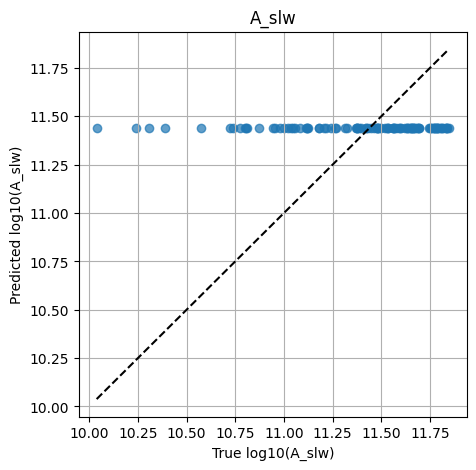

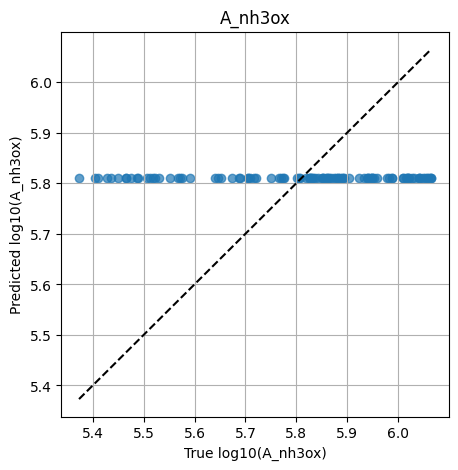

In [152]:
for j, name in enumerate(param_names):
    plt.figure(figsize=(5, 5))
    plt.scatter(np.log10(true_A_test[:, j]), np.log10(pred_A_test[:, j]), alpha=0.7)

    vmin = min(np.log10(true_A_test[:, j]).min(), np.log10(pred_A_test[:, j]).min())
    vmax = max(np.log10(true_A_test[:, j]).max(), np.log10(pred_A_test[:, j]).max())

    plt.plot([vmin, vmax], [vmin, vmax], "k--")
    plt.xlabel(f"True log10({name})")
    plt.ylabel(f"Predicted log10({name})")
    plt.title(name)
    plt.grid(True)
    plt.show()

## Optional: apply trained model to real measured downstream NOx

In [153]:
# This is for proof-of-concept real sensor trace.
# It uses R_NOx_sensor from NEDC_lite.mat as the downstream NOx input.

R_NOx_measured = get_signal("R_NOx_sensor")[::DOWNSAMPLE]
R_NOx_measured_scaled = scale_dno(R_NOx_measured)

#print("R_NOx_sensor_measured shape:", R_NOx_measured.shape)
#print("R_NOx_sensor_measured_scaled shape:", R_NOx_measured_scaled.shape)

x_real = np.concatenate(
    [base_scaled, R_NOx_measured_scaled[:, None]],
    axis=1
).astype(np.float32)

x_real_tensor = torch.from_numpy(x_real[None, :, :]).to(device)

model.eval()
with torch.no_grad():
    pred_real_scaled = model(x_real_tensor).cpu().numpy()

pred_real_A = inverse_transform_A(pred_real_scaled)[0]

#print(pred_real_A)

real_result = pd.DataFrame({
    "parameter": param_names,
    "predicted pre-exponential factor A": pred_real_A,
})

print("\nPredicted constants from real measured R_NOx_sensor:")
print(real_result)


# If your SCR simulator function expects this order:
# [k_std, k_fst, k_slw, k_ads, k_des, k_nh3ox]
# use this reorder:
pred_real_for_scr_model = pred_real_A[[2, 3, 4, 0, 1, 5]]

print("\nReordered for SCR model [A_std, A_fst, A_slw, A_ads, A_des, A_nh3ox]:")
print(pred_real_for_scr_model)


Predicted constants from real measured R_NOx_sensor:
  parameter  predicted pre-exponential factor A
0     A_ads                        4.055522e+00
1     A_des                        4.756493e+04
2     A_std                        2.725691e+09
3     A_fst                        6.638255e+09
4     A_slw                        2.741720e+11
5   A_nh3ox                        6.453607e+05

Reordered for SCR model [A_std, A_fst, A_slw, A_ads, A_des, A_nh3ox]:
[2.72569097e+09 6.63825533e+09 2.74172045e+11 4.05552154e+00
 4.75649326e+04 6.45360694e+05]


## SCR model

In [154]:
def run_scr_model(
    A_std_0,
    A_fst_0,
    A_slw_0,
    A_ads_0,
    A_des_0,
    A_nh3ox_0,
):
    import numpy as np
    import scipy.io as sio
    from scipy.integrate import solve_ivp

    # ---------- Lookup tables ----------
    NO_RATIO_BP = np.array(
        [131.3121, 161.1298, 224.8357, 265.8866, 322.246, 363.2026, 415.0273, 469.8143, 511.78],
        dtype=float,
    )
    NO_RATIO_TBL = np.array(
        [0.785714, 0.979592, 0.360825, 0.324138, 0.366906, 0.497227, 0.617626, 0.702214, 0.761749],
        dtype=float,
    )

    DENSITY_BP = np.array(
        [260, 280, 300, 350, 400, 450, 500, 600, 800, 1000, 1200, 1400],
        dtype=float,
    )
    DENSITY_TBL = np.array(
        [1.340, 1.245, 1.161, 0.995, 0.871, 0.774, 0.696, 0.580, 0.435, 0.348, 0.290, 0.249],
        dtype=float,
    )

    # ---------- Parameters ----------
    PARAMS = {
        "A_std_0": A_std_0,
        "A_fst_0": A_fst_0,
        "A_slw_0": A_slw_0,
        "A_ads_0": A_ads_0,
        "A_des_0": A_des_0,
        "A_nh3ox_0": A_nh3ox_0,
        "E1": 77300.0,
        "E2": 45200.0,
        "E3": 109000.0,
        "E4": -10200.0,
        "E5": 67500.0,
        "E6": 91100.0,
        "R": 8.314,
        "volume_m3": 0.000899,
        "ohm": 900.0,
        "switch_temp_scr_c": 190.0,
        "switch_no_ratio": 0.5,
    }

    def lookup(x, bp, table):
        return np.interp(x, bp, table, left=table[0], right=table[-1])

    def load_timeseries(mat_dict, name):
        obj = mat_dict[name][0, 0]
        t = np.asarray(obj["time"]).squeeze().astype(float)
        v = np.asarray(obj["signals"][0, 0]["values"]).squeeze().astype(float)
        return t, v

    def deduplicate_time(t, *signals):
        _, first_idx = np.unique(t, return_index=True)
        first_idx = np.sort(first_idx)
        out = [t[first_idx]]
        for s in signals:
            out.append(s[first_idx])
        return tuple(out)

    def ppm_to_molm3(ppm):
        return ppm / 22.4 / 1000.0

    def molm3_to_ppm(c):
        return c * 1000.0 * 22.4

    def rate_constants(temp_c):
        T = np.asarray(temp_c, dtype=float) + 273.15
        k_std = PARAMS["A_std_0"] * np.exp(-PARAMS["E1"] / (PARAMS["R"] * T))
        k_fst = PARAMS["A_fst_0"] * np.exp(-PARAMS["E2"] / (PARAMS["R"] * T))
        k_slw = PARAMS["A_slw_0"] * np.exp(-PARAMS["E3"] / (PARAMS["R"] * T))
        k_ads = PARAMS["A_ads_0"] * np.exp(-PARAMS["E4"] / (PARAMS["R"] * T))
        k_des = PARAMS["A_des_0"] * np.exp(-PARAMS["E5"] / (PARAMS["R"] * T))
        k_nh3ox = PARAMS["A_nh3ox_0"] * np.exp(-PARAMS["E6"] / (PARAMS["R"] * T))
        return T, k_std, k_fst, k_slw, k_ads, k_des, k_nh3ox

    def gas_exchange_factor(exhaust_mg_s, temp_c):
        T, *_ = rate_constants(temp_c)
        rho = lookup(T, DENSITY_BP, DENSITY_TBL)
        exhaust_kg_s = np.asarray(exhaust_mg_s, dtype=float) * 1e-6
        q_m3_s = exhaust_kg_s / np.maximum(rho, 1e-12)
        F = q_m3_s / PARAMS["volume_m3"]
        return T, rho, F

    def feedforward_adblue(temp_doc_up_c, nox_f_ppm, exhaust_mg_s, temp_scr_up_c):
        no_ratio = lookup(temp_doc_up_c, NO_RATIO_BP, NO_RATIO_TBL)

        mw_no = 14.007 + 15.999
        mw_no2 = 14.007 + 15.999 * 2.0
        mw_nh3 = 14.007 + 1.008 * 3.0
        mw_exh = 29.47

        c_ratio = (no_ratio * mw_no + (1.0 - no_ratio) * mw_no2) / mw_exh
        nh3_vs_nox_ratio = mw_nh3 / (no_ratio * mw_no + (1.0 - no_ratio) * mw_no2)

        exhaust_kg_s = exhaust_mg_s * 1e-6
        nox_mass_like = c_ratio * nox_f_ppm * exhaust_kg_s
        base_nh3 = nh3_vs_nox_ratio * nox_mass_like
        extra_no2_comp = base_nh3 * (1.0 - 2.0 * no_ratio) * 0.333

        alpha_ratio = np.where(
            no_ratio >= PARAMS["switch_no_ratio"],
            base_nh3,
            base_nh3 + extra_no2_comp,
        )

        urea_mg_s = alpha_ratio * (60.0 / 34.0)
        adblue_mg_s = urea_mg_s * (100.0 / 32.4)
        adblue_mg_s = np.where(temp_scr_up_c >= PARAMS["switch_temp_scr_c"], adblue_mg_s, 0.0)

        return adblue_mg_s, no_ratio

    def adblue_to_nh3_in_molm3(adblue_mg_s, exhaust_mg_s):
        return (
            ((adblue_mg_s * (32.4 / 100.0) * (34.0 / 60.0)) / np.maximum(exhaust_mg_s, 1e-12))
            * 1e6
            * (28.8 / 17.0)
            / 1000.0
            / 22.4
        )

    # ---------- Load .mat ----------
    mat = sio.loadmat(mat_path)

    t, F_NOx_sensor = load_timeseries(mat, "F_NOx_sensor")
    _, R_NOx_sensor = load_timeseries(mat, "R_NOx_sensor")
    _, Dosing = load_timeseries(mat, "Dosing")
    _, Temp = load_timeseries(mat, "Temp")
    _, ExhaustFlow = load_timeseries(mat, "ExhaustFlow")
    _, adblue_mg = load_timeseries(mat, "adblue_mg")
    _, O2 = load_timeseries(mat, "O2")
    _, Temp_DOC_up = load_timeseries(mat, "Temp_DOC_up")

    # use controller dosing exactly like your original code
    adblue_cmd, no_ratio = feedforward_adblue(Temp_DOC_up, F_NOx_sensor, ExhaustFlow, Temp)
    adblue_used = adblue_cmd

    NO_in_ppm = no_ratio * F_NOx_sensor
    NO2_in_ppm = (1.0 - no_ratio) * F_NOx_sensor

    NO_in = ppm_to_molm3(NO_in_ppm)
    NO2_in = ppm_to_molm3(NO2_in_ppm)
    NH3_in = adblue_to_nh3_in_molm3(adblue_used, ExhaustFlow)
    O2_in = O2 * 1e-2

    t_u, Temp_u, ExhaustFlow_u, O2_u, NO_in_u, NO2_in_u, NH3_in_u, R_NOx_u = deduplicate_time(
        t, Temp, ExhaustFlow, O2_in, NO_in, NO2_in, NH3_in, R_NOx_sensor
    )

    def interp_series(tt, arr):
        return float(np.interp(tt, t_u, arr, left=arr[0], right=arr[-1]))

    def rhs(tt, y):
        cno, cno2, theta, cnh3 = np.maximum(y, 0.0)

        temp_c = interp_series(tt, Temp_u)
        exh = interp_series(tt, ExhaustFlow_u)
        o2 = interp_series(tt, O2_u)
        no_in_val = interp_series(tt, NO_in_u)
        no2_in_val = interp_series(tt, NO2_in_u)
        nh3_in_val = interp_series(tt, NH3_in_u)

        _, _, F = gas_exchange_factor(exh, temp_c)
        _, k_std, k_fst, k_slw, k_ads, k_des, k_nh3ox = rate_constants(temp_c)

        Rads = k_ads * cnh3 * (1.0 - theta) * PARAMS["ohm"]
        Rdes = k_des * theta * PARAMS["ohm"]
        Roxi = k_nh3ox * o2 * theta * PARAMS["ohm"]
        Rstd = k_std * cno * o2 * theta * PARAMS["ohm"]
        Rfst = k_fst * cno * cno2 * theta * PARAMS["ohm"]
        Rslw = k_slw * cno2 * theta * PARAMS["ohm"]

        dcno = F * no_in_val - 4.0 * Rstd - 2.0 * Rfst - F * cno
        dcno2 = F * no2_in_val - 2.0 * Rfst - 3.0 * Rslw - F * cno2
        dtheta = (Rads - Rdes - 4.0 * Roxi - 4.0 * Rstd - 4.0 * Rfst - 4.0 * Rslw) / PARAMS["ohm"]
        dcnh3 = F * nh3_in_val - Rads + Rdes - 4.0 * Roxi - F * cnh3

        return np.array([dcno, dcno2, dtheta, dcnh3], dtype=float)

    sol = solve_ivp(
        rhs,
        (float(t_u[0]), float(t_u[-1])),
        y0=np.array([0.0, 0.0, 0.0, 0.0], dtype=float),
        t_eval=t_u,
        method="BDF",
        rtol=1e-5,
        atol=1e-8,
    )

    if not sol.success:
        raise RuntimeError(f"ODE solve failed: {sol.message}")

    cno_u, cno2_u, theta_u, cnh3_u = sol.y

    cno = np.interp(t, t_u, cno_u)
    cno2 = np.interp(t, t_u, cno2_u)
    cnh3 = np.interp(t, t_u, cnh3_u)

    NO_out_ppm = molm3_to_ppm(cno)
    NO2_out_ppm = molm3_to_ppm(cno2)
    NH3_out_ppm = molm3_to_ppm(cnh3)

    Model_NOx_ppm = NO_out_ppm + NO2_out_ppm
    Model_sensor_ppm = Model_NOx_ppm + NH3_out_ppm

    return t, Model_sensor_ppm

## Run SCR model

In [155]:
pred_real_A = np.asarray(pred_real_A, dtype=np.float64).reshape(-1)

print("pred_real_A shape:", pred_real_A.shape)
print(pred_real_A)

if pred_real_A.size != 6:
    raise ValueError(f"Expected 6 predicted constants, but got shape {pred_real_A.shape}")

A_ads, A_des, A_std, A_fst, A_slw, A_nh3ox = pred_real_A

time_s, Model_sensor_ppm = run_scr_model(
    A_std_0=float(A_std),
    A_fst_0=float(A_fst),
    A_slw_0=float(A_slw),
    A_ads_0=float(A_ads),
    A_des_0=float(A_des),
    A_nh3ox_0=float(A_nh3ox),
)

print("SCR model finished.")
print("time_s shape:", np.shape(time_s))
print("Model_sensor_ppm shape:", np.shape(Model_sensor_ppm))

pred_real_A shape: (6,)
[4.05552154e+00 4.75649326e+04 2.72569097e+09 6.63825533e+09
 2.74172045e+11 6.45360694e+05]
SCR model finished.
time_s shape: (11993,)
Model_sensor_ppm shape: (11993,)


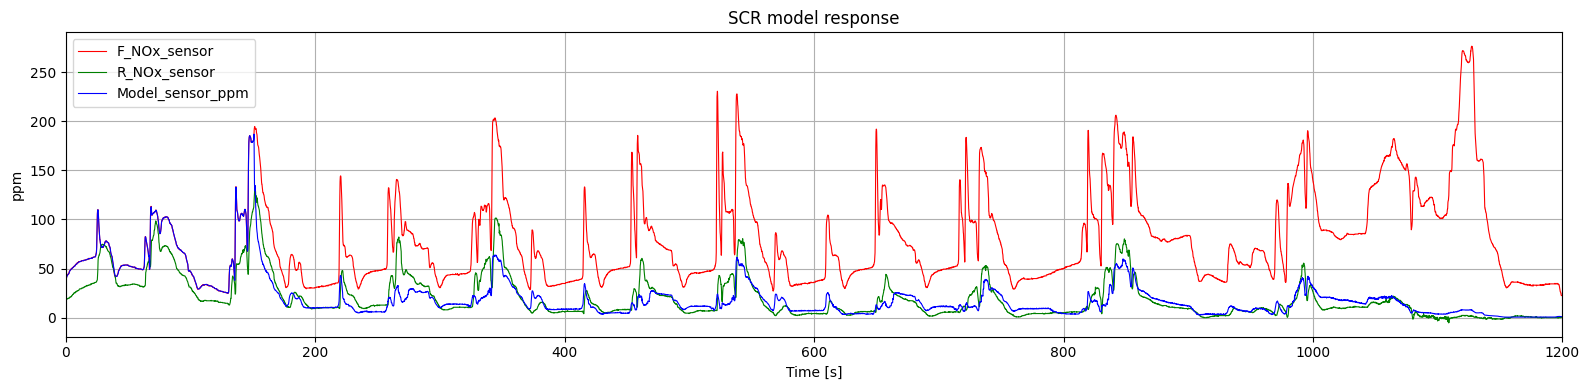

In [156]:
import matplotlib.pyplot as plt
import scipy.io as sio
import numpy as np

# Define load_timeseries function here so it's accessible
def load_timeseries(mat_dict, name):
    obj = mat_dict[name][0, 0]
    t = np.asarray(obj["time"]).squeeze().astype(float)
    v = np.asarray(obj["signals"][0, 0]["values"]).squeeze().astype(float)
    return t, v

# ---- Load only the two measured signals for plotting ----
mat = sio.loadmat(mat_path)

t_f, F_NOx_sensor = load_timeseries(mat, "F_NOx_sensor")
t_r, R_NOx_sensor = load_timeseries(mat, "R_NOx_sensor")

# ---- Plot ----
plt.figure(figsize=(16, 4))
plt.plot(t_f, F_NOx_sensor, label="F_NOx_sensor", color='red', linewidth=0.8)
plt.plot(t_r, R_NOx_sensor, label="R_NOx_sensor", color='green', linewidth=0.8)
plt.plot(time_s, Model_sensor_ppm, label="Model_sensor_ppm", color='blue', linewidth=0.8)

plt.xlim(0, 1200)   # optional
plt.xlabel("Time [s]")
plt.ylabel("ppm")
plt.title("SCR model response")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()



Error between R_NOx_sensor and Model_sensor_ppm
L2 error          = 1.518716e+03
Relative L2 error = 4.782479e-01
RMSE              = 13.867960 ppm
MAE               = 8.704182 ppm


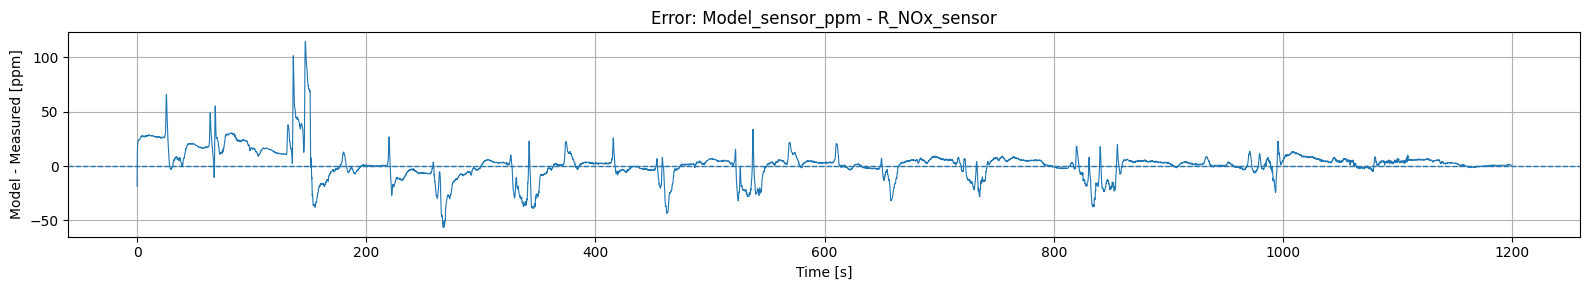

In [157]:
# ------------------------------------------------------------
# Load measured downstream NOx: R_NOx_sensor
# ------------------------------------------------------------
mat_path = "../Data/NEDC_lite.mat"

mat_real = sio.loadmat(
    mat_path,
    squeeze_me=True,
    struct_as_record=False
)

def get_signal_from_mat(mat_dict, name):
    obj = mat_dict[name]
    t = np.asarray(obj.time, dtype=float).reshape(-1)
    v = np.asarray(obj.signals.values, dtype=float).reshape(-1)
    return t, v

t_r, R_NOx_sensor = get_signal_from_mat(mat_real, "R_NOx_sensor")


# ------------------------------------------------------------
# Interpolate model output to measured R_NOx_sensor time
# ------------------------------------------------------------
Model_sensor_interp = np.interp(
    t_r,
    time_s,
    Model_sensor_ppm
)


# ------------------------------------------------------------
# L2 error
# ------------------------------------------------------------
error = Model_sensor_interp - R_NOx_sensor

l2_error = np.linalg.norm(error, ord=2)
relative_l2_error = l2_error / (np.linalg.norm(R_NOx_sensor, ord=2) + 1e-12)

mse = np.mean(error**2)
rmse = np.sqrt(mse)
mae = np.mean(np.abs(error))

print("Error between R_NOx_sensor and Model_sensor_ppm")
print(f"L2 error          = {l2_error:.6e}")
print(f"Relative L2 error = {relative_l2_error:.6e}")
print(f"RMSE              = {rmse:.6f} ppm")
print(f"MAE               = {mae:.6f} ppm")


# ------------------------------------------------------------
# Plot error
# ------------------------------------------------------------
plt.figure(figsize=(16, 3))
plt.plot(t_r, error, linewidth=0.8)
plt.axhline(0.0, linestyle="--", linewidth=1.0)
plt.xlabel("Time [s]")
plt.ylabel("Model - Measured [ppm]")
plt.title("Error: Model_sensor_ppm - R_NOx_sensor")
plt.grid(True)
plt.tight_layout()
plt.show()

Error between R_NOx_sensor and Model_sensor_ppm
L2 error          = 1.542102e+03
Relative L2 error = 4.856124e-01
RMSE              = 14.081510 ppm
MAE               = 8.652655 ppm


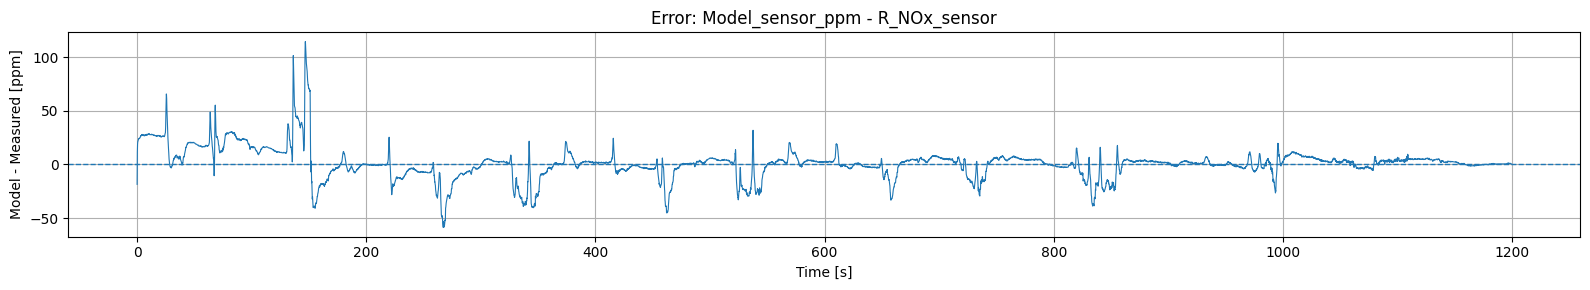

In [158]:
time_s, Model_sensor_ppm = run_scr_model(
    A_std_0=3.59e9,
    A_fst_0=8.80e9,
    A_slw_0=3.56e11,
    A_ads_0=4.32,
    A_des_0=4.83e4,
    A_nh3ox_0=6.99e5,
)

# ------------------------------------------------------------
# Load measured downstream NOx: R_NOx_sensor
# ------------------------------------------------------------
mat_path = "../Data/NEDC_lite.mat"

mat_real = sio.loadmat(
    mat_path,
    squeeze_me=True,
    struct_as_record=False
)

def get_signal_from_mat(mat_dict, name):
    obj = mat_dict[name]
    t = np.asarray(obj.time, dtype=float).reshape(-1)
    v = np.asarray(obj.signals.values, dtype=float).reshape(-1)
    return t, v

t_r, R_NOx_sensor = get_signal_from_mat(mat_real, "R_NOx_sensor")


# ------------------------------------------------------------
# Interpolate model output to measured R_NOx_sensor time
# ------------------------------------------------------------
Model_sensor_interp = np.interp(
    t_r,
    time_s,
    Model_sensor_ppm
)


# ------------------------------------------------------------
# L2 error
# ------------------------------------------------------------
error = Model_sensor_interp - R_NOx_sensor

l2_error = np.linalg.norm(error, ord=2)
relative_l2_error = l2_error / (np.linalg.norm(R_NOx_sensor, ord=2) + 1e-12)

mse = np.mean(error**2)
rmse = np.sqrt(mse)
mae = np.mean(np.abs(error))

print("Error between R_NOx_sensor and Model_sensor_ppm")
print(f"L2 error          = {l2_error:.6e}")
print(f"Relative L2 error = {relative_l2_error:.6e}")
print(f"RMSE              = {rmse:.6f} ppm")
print(f"MAE               = {mae:.6f} ppm")


# ------------------------------------------------------------
# Plot error
# ------------------------------------------------------------
plt.figure(figsize=(16, 3))
plt.plot(t_r, error, linewidth=0.8)
plt.axhline(0.0, linestyle="--", linewidth=1.0)
plt.xlabel("Time [s]")
plt.ylabel("Model - Measured [ppm]")
plt.title("Error: Model_sensor_ppm - R_NOx_sensor")
plt.grid(True)
plt.tight_layout()
plt.show()